# Key steering

Layer 22 seems to be the most interpretable. Let's steer it!

- Train linear regression
- Switch up activations
- Regenerate

Let's work backwards. Does regeneration work?

In [15]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from IPython.display import Audio

In [9]:
import torch
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import scipy.io.wavfile as wavfile

# Load model
processor = AutoProcessor.from_pretrained("facebook/musicgen-large")
model = MusicgenForConditionalGeneration.from_pretrained("facebook/musicgen-large").to("cuda")
model.eval()

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.95it/s]


MusicgenForConditionalGeneration(
  (text_encoder): T5EncoderModel(
    (shared): Embedding(32128, 768)
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 768)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=768, out_features=768, bias=False)
                (k): Linear(in_features=768, out_features=768, bias=False)
                (v): Linear(in_features=768, out_features=768, bias=False)
                (o): Linear(in_features=768, out_features=768, bias=False)
                (relative_attention_bias): Embedding(32, 12)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseActDense(
                (wi): Linear(in_features=768, out_features=3072, bias=False)
                (wo): L

In [10]:
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json"

with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

LAYER_IDX = 22

In [11]:
# Train logistic regression on layer 22
import sys
sys.path.append("../linear_probe")
from linear_probe_key import train_linear_probe, logger

In [7]:
linear_probe_res = list(train_linear_probe(22, 128, "max", train=False))
print(linear_probe_res)
logger.setLevel("ERROR")

[2025-12-09 14:21:03] Logistic regression on layer_idx=22
[2025-12-09 14:21:03] Pooling...
[2025-12-09 14:21:04] Normalizing...
[2025-12-09 14:21:04] Running pca...
[2025-12-09 14:21:06] Making test splits...


[layer_idx=22]  train_acc=75.000%, test_acc=60.278
[(LogisticRegression(), PCA(n_components=128), StandardScaler()), (0.75, 0.6027777777777777)]


Found minor steering vector:
(2048,)
[ 0.0173482   0.00266348 -0.00931891  0.00384093  0.00098093 -0.01825728
 -0.01749083  0.00260097  0.01303645  0.00813215]


Text(0, 0.5, 'Minor steering vector importance')

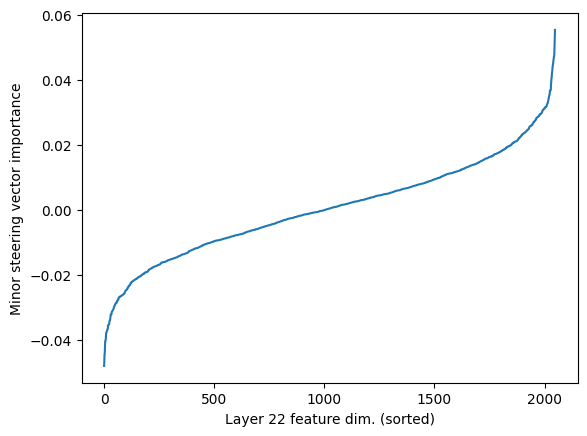

In [12]:
reg, pca, scaler = linear_probe_res[0]
minor_steer_vec = reg.coef_[0] @ pca.components_

print(f"Found minor steering vector:")
print(minor_steer_vec.shape)
print(minor_steer_vec[:10])
plt.plot(sorted(minor_steer_vec))
plt.xlabel(f"Layer {LAYER_IDX} feature dim. (sorted)")
plt.ylabel("Minor steering vector importance")

In [68]:
# Load your saved activations - shape (256, 2048)
clip_idx = 25
clip = metadata[clip_idx]

from pprint import pprint
pprint(clip)

act_path = clip["activations_path"]
acts = torch.load(act_path)

# Assuming this is the layer 22 output; add batch dim if needed
layer_acts = acts["decoder.model.decoder.layers.22"]  # adjust key as needed
layer_acts = torch.cat(layer_acts, dim=1).to("cuda")

print(layer_acts.shape)
print(minor_steer_vec.shape)

Audio(clip["audio_path"])

{'activations_path': '/home/harinit9/orcd/pool/musicgen-data-nokey/activations/0025.pt',
 'audio_path': '/home/harinit9/orcd/pool/musicgen-data-nokey/audio/0025.wav',
 'clip_id': '0025',
 'detected_key': 'G_major',
 'key_info': {'confidence': 0.2557591774177793,
              'error': None,
              'key': 'G_major',
              'mode': 'major',
              'note': 'G'},
 'label_key': 'G_major',
 'midi_path': '/home/harinit9/orcd/pool/musicgen-data-nokey/midi/0025_basic_pitch.mid',
 'prompt': 'happy solo piano, up-tempo, using romantic style and flowing '
           'sixteenth-note runs.',
 'sampling_rate': 32000}
torch.Size([2, 256, 2048])
(2048,)


In [95]:
# Track generation step
step_counter = [0]

alpha = 15.0
steering_vec = torch.tensor(minor_steer_vec, device="cuda", dtype=torch.float32)

def patch_hook(module, inp, out):
    """Replace layer 22 output with saved activations at each step."""
    return (out[0] + alpha * steering_vec,)

# Find and hook layer 22
print(f"Finding and hooking layer {LAYER_IDX}...")
for name, module in model.decoder.named_modules():
    if name == f"model.decoder.layers.{LAYER_IDX}":
        module._forward_hooks.clear()
        handle = module.register_forward_hook(patch_hook)
        break

print(f"Prompt: {clip['prompt']}")
inputs = processor(
    text=clip["prompt"],
    padding=True,
    return_tensors="pt",
).to("cuda")

with torch.no_grad():
    print("Generating...")
    audio_values = model.generate(
        **inputs,
        do_sample=False,  # deterministic since we're patching
        max_new_tokens=256,
    )

handle.remove()

# Save audio (5s)
clip_np = audio_values[0, 0].cpu().numpy()

save_path = f"{clip_idx:02d}_reconstructed.wav"
wavfile.write(save_path, rate=32000, data=clip_np)
print(f"Saved to {save_path}")

Finding and hooking layer 22...
Prompt: happy solo piano, up-tempo, using romantic style and flowing sixteenth-note runs.
Generating...
Saved to 25_reconstructed.wav


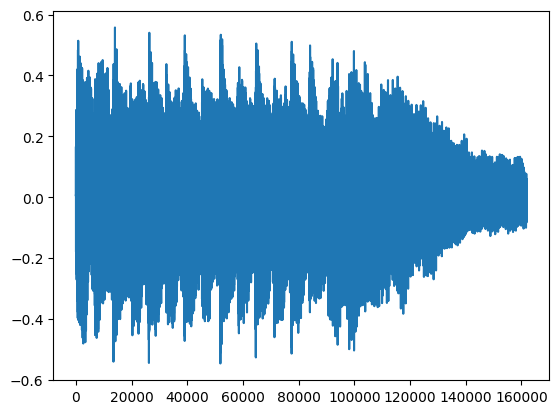

In [96]:
from IPython.display import Audio

plt.plot(clip_np)
Audio(clip_np, rate=32000, normalize=False)

In [78]:
Audio(clip["audio_path"])

In [ ]:
plt.scatter(
    steering_vec.cpu(),
    layer_acts[0,10].cpu(),
)
plt.xlabel("Steering vector")
plt.ylabel(f"Layer {LAYER_IDX} activations")